In [126]:
import os
import json
import pickle
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.transforms as T
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torch_geometric.nn.attention import PerformerAttention
from torch_geometric.nn.attention.performer import generalized_kernel
from torch_geometric.nn import GATv2Conv
from shapely.geometry import Point, LineString, Polygon

import numpy as np
import pandas as pd
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
from collections import Counter
import torch_geometric
from torch_geometric.data import Data
from shapely import wkt
import contextily as cx
import h3pandas
import seaborn as sns
from utils import *

# Feature Augmentation and Attention Behavior

This notebook explores how adding urban features (population, POI density, land use) to spatial-only graph data affects attention distributions 

Goals:
- Test if multimodal attention patterns vanish with richer features
- Analyze effect of removing positional encoding and recentering the graph

Focus is on interpretability and internal changes in attention with minimal vs enriched inputs.


In [127]:
#load paris geoJson edge and nodes
paris_edges = gpd.read_file('paris_edges.geojson')
paris_nodes = gpd.read_file('paris_nodes.geojson')

#save nodes and edges to geojson
h3_edges = gpd.read_file('h3_edges.geojson')
h3_nodes = gpd.read_file('h3_nodes.geojson')
h3_nodes.index = h3_nodes['h3_09'] 
h3_nodes.drop(columns=['h3_09'], inplace=True)
print(h3_nodes.columns)

Skipping field osmid: unsupported OGR type: 13


Index(['x', 'y', 'Node Density', 'Street Length', 'Degree', 'Clustering',
       'Clustering (Weighted)', 'Closeness Centrality',
       'Betweenness Centrality', 'Eigenvector Centrality', 'Katz Centrality',
       'PageRank', 'Footprint Proportion', 'Footprint Mean', 'Footprint Stdev',
       'Perimeter Total', 'Perimeter Mean', 'Perimeter Stdev',
       'Complexity Mean', 'Complexity Stdev', 'Counts', 'PopSum', 'Men',
       'Women', 'Elderly', 'Youth', 'Children', 'Civic', 'Commercial',
       'Entertainment', 'Food', 'Healthcare', 'Institutional', 'Recreational',
       'Social', 'Green View', 'Sky View', 'Building View', 'Road View',
       'geometry'],
      dtype='object')


Computing central hex 

Central hexagon ID: 891fb467527ffff, Coordinates: (2.3443477758208773, 48.856727989429906)


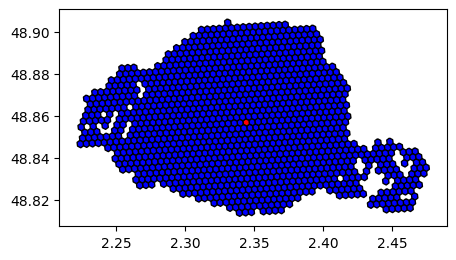

In [128]:
mean_x = h3_nodes['x'].mean()
mean_y = h3_nodes['y'].mean()
h3_nodes['dist_to_mean'] = (h3_nodes['x'] - mean_x)**2 + (h3_nodes['y'] - mean_y)**2
central_hex_id = h3_nodes['dist_to_mean'].idxmin()
central_hex_x = h3_nodes.loc[central_hex_id, 'x']
central_hex_y = h3_nodes.loc[central_hex_id, 'y']
h3_nodes.drop(columns=['dist_to_mean'], inplace=True)

node_color = ['red' if idx == central_hex_id else 'blue' for idx in h3_nodes.index]
f, ax = plt.subplots(figsize=(5, 5))
h3_nodes.plot(ax=ax, color=node_color, markersize=10, edgecolor='black')

print(f"Central hexagon ID: {central_hex_id}, Coordinates: ({central_hex_x}, {central_hex_y})")


In [129]:
h3_nodes['x'] = h3_nodes['x'] - central_hex_x
h3_nodes['y'] = h3_nodes['y'] - central_hex_y

h3_nodes.head()

,x,y,Node Density,Street Length,Degree,Clustering,Clustering (Weighted),Closeness Centrality,Betweenness Centrality,Eigenvector Centrality,...,Food,Healthcare,Institutional,Recreational,Social,Green View,Sky View,Building View,Road View,geometry
h3_09,,,,,,,,,,,,,,,,,,,,,
891fb460d83ffff,-0.072768,-0.029696,35.560000,4607.870271,2.360000,0.0000,0.000000,0.020330,0.000400,4.667650e-11,...,162.0,0.0,5.0,169.0,5.0,0.185865,0.151214,0.251172,0.172528,"POLYGON ((2.27124 48.8288, 2.26925 48.82783, 2..."
891fb460d87ffff,-0.068446,-0.029518,31.812500,3992.693797,2.562500,0.0625,0.000698,0.021747,0.001017,1.440199e-10,...,108.0,0.0,0.0,134.0,0.0,0.185865,0.151214,0.251172,0.172528,"POLYGON ((2.27557 48.82898, 2.27357 48.828, 2...."
891fb460d93ffff,-0.075433,-0.027134,26.466667,4718.117299,2.400000,0.0000,0.000000,0.019602,0.000146,3.043977e-16,...,86.0,0.0,56.0,90.0,1.0,0.185865,0.151214,0.251172,0.172528,"POLYGON ((2.26858 48.83136, 2.26659 48.83039, ..."
891fb460d97ffff,-0.071111,-0.026955,21.333333,3561.154014,1.666667,0.0000,0.000000,0.020608,0.000278,2.203064e-16,...,19.0,0.0,0.0,21.0,0.0,0.185865,0.151214,0.251172,0.172528,"POLYGON ((2.2729 48.83154, 2.27091 48.83057, 2..."
891fb460d9bffff,-0.077090,-0.029875,31.333333,4092.815318,2.428571,0.0000,0.000000,0.020462,0.000486,5.513984e-11,...,145.0,0.0,81.0,150.0,21.0,0.185865,0.151214,0.251172,0.172528,"POLYGON ((2.26692 48.82862, 2.26493 48.82765, ..."


In [130]:
h3_nodes['Entertainment'].head()


h3_09
891fb460d83ffff     1.0
891fb460d87ffff     0.0
891fb460d93ffff    25.0
891fb460d97ffff     1.0
891fb460d9bffff    24.0
Name: Entertainment, dtype: float64

In [131]:
device = 'cpu'
print(device)
basicHexes = h3_nodes.copy()
basicHexes = basicHexes[['Green View', 'geometry', 'x', 'y']]
y = basicHexes['Green View'].values
X = basicHexes[['x', 'y']].values
X = np.array(X)
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)
node_mapping = {node_id: idx for idx, node_id in enumerate(h3_nodes.index)}
reverse_mapping = {idx: h3_id for h3_id, idx in node_mapping.items()}
edge_index = []
for _, row in h3_edges.iterrows():
    source_idx = node_mapping[row['source']]
    target_idx = node_mapping[row['target']]
    edge_index.append([source_idx, target_idx]) # no need to add the reverse edge since edge already contains it
edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
transform = T.AddRandomWalkPE(20, attr_name= 'pe')
BasicData = Data(x = torch.FloatTensor(X_scaled), y = torch.FloatTensor(y), edge_index = edge_index )
BasicData = transform(BasicData)
np.random.seed(0)
n_nodes = BasicData.num_nodes
indices = np.random.permutation(n_nodes)
train_idx = indices[:int(0.7 * n_nodes)]
val_idx = indices[int(0.7 * n_nodes):int(0.85 * n_nodes)]
test_idx = indices[int(0.85 * n_nodes):]
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_nodes, dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True        
BasicData.train_mask = train_mask   
BasicData.val_mask = val_mask
BasicData.test_mask = test_mask
BasicData.to(device)

cpu


Data(x=[1228, 2], edge_index=[2, 6844], y=[1228], pe=[1228, 20], train_mask=[1228], val_mask=[1228], test_mask=[1228])

Usual model but without positional encoding

In [132]:
class HybridModel_variant(nn.Module):
    def __init__(
        self,
        in_channels: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        num_transformer_layers: int = 2,
        num_gat_layers: int = 2,
        dropout: float = 0.4,
        combine_method: str = 'concat',  # 'concat', 'sum'
    ):
        super().__init__()
        
        # Shared input embedding
        self.node_emb = nn.Linear(in_channels, hidden_channels)
       
        
        # Transformer branch (DeepGraphPerformer)
        self.transformer_layers = nn.ModuleList()
        for _ in range(num_transformer_layers):
            layer = nn.ModuleDict({
                'norm1': nn.LayerNorm(hidden_channels),
                'attention': PerformerAttention(
                    channels=hidden_channels,
                    heads=heads,
                    head_channels=head_channels,
                    kernel=torch.nn.ReLU(),
                    dropout=dropout
                ),
                'norm2': nn.LayerNorm(hidden_channels),
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.transformer_layers.append(layer)
        
        # GAT branch - improved with proper normalization and FFN
        self.gat_layers = nn.ModuleList()
        for _ in range(num_gat_layers):
            layer = nn.ModuleDict({
                # Pre-normalization
                'norm': nn.LayerNorm(hidden_channels),
                
                # GAT component
                'gat': GATv2Conv(
                    hidden_channels, 
                    hidden_channels, 
                    heads=heads, 
                    concat=True, 
                    dropout=dropout
                ),
                
                # Post-normalization
                'gat_norm': nn.LayerNorm(hidden_channels*heads),
                
                # Feed-forward network
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels*heads, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.gat_layers.append(layer)
        
        # Layer normalization for transformer and GAT outputs before combining
        self.transformer_norm = nn.LayerNorm(hidden_channels)
        self.gat_norm = nn.LayerNorm(hidden_channels)
        
        # Combination method
        self.combine_method = combine_method
        if combine_method == 'concat':
            self.combine = nn.Linear(hidden_channels * 2, hidden_channels)
        
        # Output layer for node prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def forward(self, x, pe ,edge_index, branch='both'):
        """
        Forward pass with option to use specific branches.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            branch: Which branch to use ('both', 'gat', or 'performer')
        """
        # Input embedding
        x = self.node_emb(x)

        if branch in ['both', 'performer']:
            # Transformer branch
            transformer_x = x
            for layer in self.transformer_layers:
                # Attention block with residual
                residual = transformer_x
                transformer_x_norm = layer['norm1'](transformer_x)
                transformer_x_attn = transformer_x_norm.unsqueeze(0)
                transformer_x_attn = layer['attention'](transformer_x_attn)
                transformer_x = transformer_x_attn.squeeze(0) + residual
                
                # FFN block with residual
                residual = transformer_x
                transformer_x = layer['norm2'](transformer_x)
                transformer_x = layer['ffn'](transformer_x) + residual
            
            transformer_x = self.transformer_norm(transformer_x)
        
        if branch in ['both', 'gat']:
            # GAT branch - improved with proper residuals and FFN
            gat_x = x
            for layer in self.gat_layers:
                # Pre-normalization
                gat_x_norm = layer['norm'](gat_x)
                
                # Apply GAT 
                gat_x_attn = layer['gat'](gat_x_norm, edge_index)
                gat_x_attn = layer['gat_norm'](gat_x_attn)
                
                # Apply FFN with residual
                gat_x_ff = layer['ffn'](gat_x_attn)
                
                # Add residual connection from before GAT (matches GAT_model design)
                gat_x = gat_x + gat_x_ff
            
            gat_x = self.gat_norm(gat_x)
        
        # Combine or use individual branch based on parameter
        if branch == 'both':
            if self.combine_method == 'sum':
                combined_x = transformer_x + gat_x
            elif self.combine_method == 'concat':
                combined_x = torch.cat([transformer_x, gat_x], dim=1)
                combined_x = F.relu(self.combine(combined_x))
        elif branch == 'performer':
            combined_x = transformer_x
        elif branch == 'gat':
            combined_x = gat_x
        
        # Final prediction
        return self.output_layer(combined_x)
    
    def redraw_projection_matrix(self):
        """Redraw projection matrices in all attention layers."""
        for layer in self.transformer_layers:
            attention = layer['attention']
            attention.redraw_projection_matrix()
    
    def get_performer_attention(self, x, pe, edge_index ,layer_idx=0, mask=None):
        """Extract the attention approximation used by Performer for a specific layer.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            layer_idx: Index of the layer to extract attention from (default: 0)
            mask: Optional mask
            
        Returns:
            Tensor of shape [heads, num_nodes, num_nodes] representing attention weights
        """
        if layer_idx < 0 or layer_idx >= len(self.transformer_layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.transformer_layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x = self.node_emb(x)
            transformer_x = x
            
            # Process through previous transformer layers
            for i in range(layer_idx):
                layer = self.transformer_layers[i]
                # Attention block with residual
                residual = transformer_x
                transformer_x_norm = layer['norm1'](transformer_x)
                transformer_x_attn = transformer_x_norm.unsqueeze(0)
                transformer_x_attn = layer['attention'](transformer_x_attn)
                transformer_x = transformer_x_attn.squeeze(0) + residual
                
                # FFN block with residual
                residual = transformer_x
                transformer_x = layer['norm2'](transformer_x)
                transformer_x = layer['ffn'](transformer_x) + residual
            
            # Get the target layer
            layer = self.transformer_layers[layer_idx]
            transformer_x_norm = layer['norm1'](transformer_x)
            
            # Add batch dimension for attention
            x = transformer_x_norm.unsqueeze(0)
            
            # Get Q, K, V projections
            attention = layer['attention']
            B, N, C = x.shape
            q, k, v = attention.q(x), attention.k(x), attention.v(x)
            
            # Reshape to multi-head format
            q, k, v = map(
                lambda t: t.reshape(B, N, attention.heads, attention.head_channels).permute(
                    0, 2, 1, 3), (q, k, v))
            
            # Apply the kernel approximation to q and k
            fast_attn = attention.fast_attn
            q_prime = generalized_kernel(q, fast_attn.projection_matrix, fast_attn.kernel)
            k_prime = generalized_kernel(k, fast_attn.projection_matrix, fast_attn.kernel)
            
            # Compute approximate attention matrix
            k_prime_sum = k_prime.sum(dim=-2, keepdim=True)
            
            # For explicit attention weights
            attention_weights = []
            for h in range(attention.heads):
                head_q = q_prime[0, h]  # [N, features]
                head_k = k_prime[0, h]  # [N, features]
                
                # Compute normalized attention (shape: [N, N])
                attn_mat = torch.zeros(N, N, device=q.device)
                for i in range(N):
                    q_i = head_q[i:i+1]  # [1, features]
                    # Normalized kernel dot product for each node pair
                    attn_i = (q_i @ head_k.transpose(-1, -2)) / (q_i @ k_prime_sum[0, h].transpose(-1, -2))
                    attn_mat[i] = attn_i
                
                attention_weights.append(attn_mat)
            
            return torch.stack(attention_weights)  # [heads, N, N]
    
    def get_attention_weights(self, x, pe ,edge_index, layer_idx=0):
        """Extract the attention weights from GATv2Conv for a specific layer.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            layer_idx: Index of the layer to extract attention from (default: 0)
            
        Returns:
            Tuple of (edge_index, attention_weights) where attention_weights has
            shape [num_edges, heads]
        """
        if layer_idx < 0 or layer_idx >= len(self.gat_layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.gat_layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x = self.node_emb(x)
            gat_x = x
            
            # Process through previous layers using the proper GAT layer structure
            for i in range(layer_idx):
                layer = self.gat_layers[i]
                # Pre-normalization
                gat_x_norm = layer['norm'](gat_x)
                
                # Apply GAT 
                gat_x_attn = layer['gat'](gat_x_norm, edge_index)
                gat_x_attn = layer['gat_norm'](gat_x_attn)
                
                # Apply FFN with residual
                gat_x_ff = layer['ffn'](gat_x_attn)
                
                # Add residual connection from before GAT
                gat_x = gat_x + gat_x_ff
            
            # Get the target layer
            layer = self.gat_layers[layer_idx]
            gat_x_norm = layer['norm'](gat_x)
            
            # Return the edge_index and attention weights for the target layer
            # For GATv2Conv, we need to use return_attention_weights=True
            _, (att_edge_ind, attention_weights) = layer['gat'](
                gat_x_norm, edge_index, return_attention_weights=True)
            
            # The attention weights will have shape [num_edges, heads]
            return att_edge_ind, attention_weights
        

# Initialize the model
model_basic = HybridModel_variant(
    in_channels=BasicData.num_features,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_transformer_layers=4,
    num_gat_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model_basic.to(device)
assert model_basic(BasicData.x, BasicData.pe ,BasicData.edge_index).squeeze().shape == BasicData.y.shape, "Model output shape does not match target shape"

In [133]:
LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_basic.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30

# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(model_basic, BasicData, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(model_basic, BasicData, BasicData.val_mask, criterion)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        #torch.save(model_basic.state_dict(), 'best_models_paris/best_hybrid_variant_model_basic.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    # Print progress
    if epoch % 10 == 0:
        test_loss = evaluate(model_basic, BasicData, BasicData.test_mask, criterion)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, Counter: {early_stop_counter}')
    
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0257, Val Loss: 0.0104, Test Loss: 0.0093, Counter: 0
Epoch: 020, Train Loss: 0.0116, Val Loss: 0.0093, Test Loss: 0.0070, Counter: 9
Epoch: 030, Train Loss: 0.0089, Val Loss: 0.0087, Test Loss: 0.0065, Counter: 19
Epoch: 040, Train Loss: 0.0084, Val Loss: 0.0082, Test Loss: 0.0061, Counter: 0
Epoch: 050, Train Loss: 0.0081, Val Loss: 0.0082, Test Loss: 0.0061, Counter: 6
Epoch: 060, Train Loss: 0.0080, Val Loss: 0.0080, Test Loss: 0.0060, Counter: 0
Epoch: 070, Train Loss: 0.0077, Val Loss: 0.0079, Test Loss: 0.0059, Counter: 0
Epoch: 080, Train Loss: 0.0081, Val Loss: 0.0077, Test Loss: 0.0059, Counter: 0
Epoch: 090, Train Loss: 0.0078, Val Loss: 0.0077, Test Loss: 0.0059, Counter: 1
Epoch: 100, Train Loss: 0.0078, Val Loss: 0.0075, Test Loss: 0.0058, Counter: 0
Epoch: 110, Train Loss: 0.0075, Val Loss: 0.0075, Test Loss: 0.0058, Counter: 5
Epoch: 120, Train Loss: 0.0077, Val Loss: 0.0073, Test Loss: 0.0057, Counter: 0
Epoch: 130,

Final Test Results - Loss: 0.0055


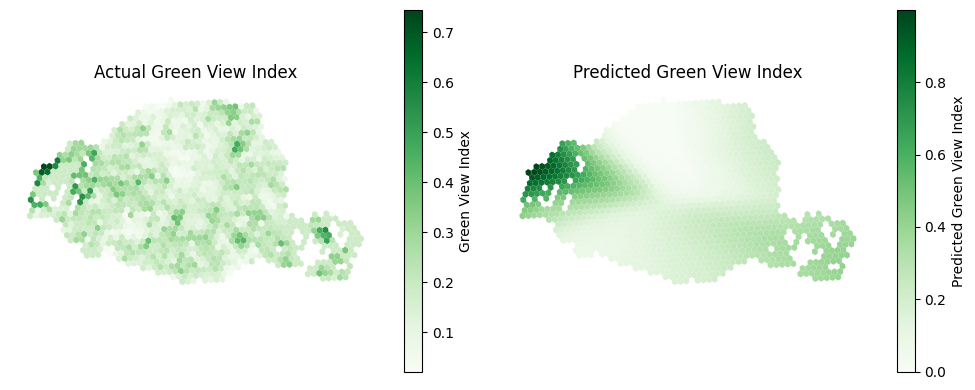

In [134]:
evaluate_and_visualize_predictions(model_basic, BasicData, '', h3_nodes, criterion, branch='both')

## Adding a feature to the data


In [135]:
X = h3_nodes[['x', 'y','PopSum']].values
X = np.array(X)
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)
BasicData = Data(x = torch.FloatTensor(X_scaled), y = torch.FloatTensor(y), edge_index = edge_index )
BasicData = transform(BasicData)
BasicData.train_mask = train_mask   
BasicData.val_mask = val_mask
BasicData.test_mask = test_mask
BasicData.to(device)

Data(x=[1228, 3], edge_index=[2, 6844], y=[1228], pe=[1228, 20], train_mask=[1228], val_mask=[1228], test_mask=[1228])

In [136]:
# Initialize the model
model_basic = HybridModel_variant(
    in_channels=BasicData.num_features,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_transformer_layers=4,
    num_gat_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model_basic.to(device)
assert model_basic(BasicData.x, BasicData.pe ,BasicData.edge_index).squeeze().shape == BasicData.y.shape, "Model output shape does not match target shape"

In [137]:
LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_basic.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30

# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(model_basic, BasicData, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(model_basic, BasicData, BasicData.val_mask, criterion)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        #torch.save(model_basic.state_dict(), 'best_models_paris/best_hybrid_variant_model_basic.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    # Print progress
    if epoch % 10 == 0:
        test_loss = evaluate(model_basic, BasicData, BasicData.test_mask, criterion)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, Counter: {early_stop_counter}')
    
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0306, Val Loss: 0.0207, Test Loss: 0.0165, Counter: 3
Epoch: 020, Train Loss: 0.0130, Val Loss: 0.0090, Test Loss: 0.0063, Counter: 2
Epoch: 030, Train Loss: 0.0098, Val Loss: 0.0084, Test Loss: 0.0059, Counter: 12
Epoch: 040, Train Loss: 0.0103, Val Loss: 0.0087, Test Loss: 0.0062, Counter: 22
Epoch: 050, Train Loss: 0.0088, Val Loss: 0.0079, Test Loss: 0.0057, Counter: 0
Epoch: 060, Train Loss: 0.0084, Val Loss: 0.0082, Test Loss: 0.0058, Counter: 10
Epoch: 070, Train Loss: 0.0080, Val Loss: 0.0079, Test Loss: 0.0057, Counter: 20
Epoch: 080, Train Loss: 0.0079, Val Loss: 0.0078, Test Loss: 0.0058, Counter: 0
Epoch: 090, Train Loss: 0.0082, Val Loss: 0.0078, Test Loss: 0.0058, Counter: 7
Epoch: 100, Train Loss: 0.0075, Val Loss: 0.0077, Test Loss: 0.0057, Counter: 0
Epoch: 110, Train Loss: 0.0076, Val Loss: 0.0076, Test Loss: 0.0056, Counter: 0
Epoch: 120, Train Loss: 0.0078, Val Loss: 0.0075, Test Loss: 0.0056, Counter: 0
Epoch: 1

Final Test Results - Loss: 0.0056


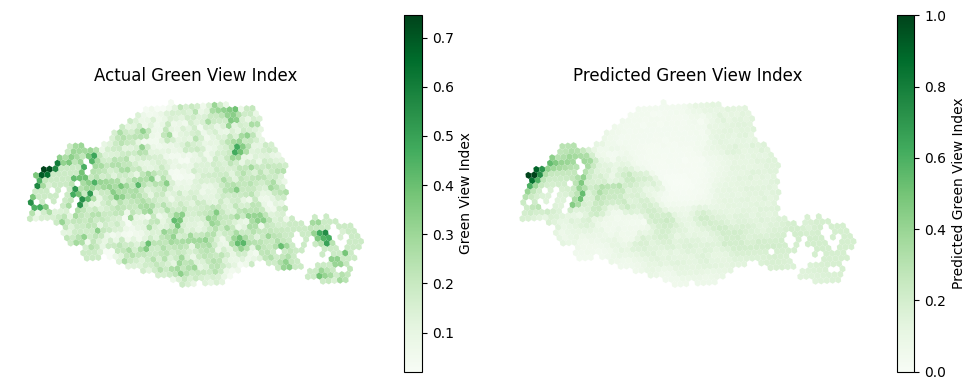

In [138]:
evaluate_and_visualize_predictions(model_basic, BasicData, 'best_models_paris/best_hybrid_variant_model_basic.pth', h3_nodes, criterion, branch='both')

torch.Size([1228, 1228])


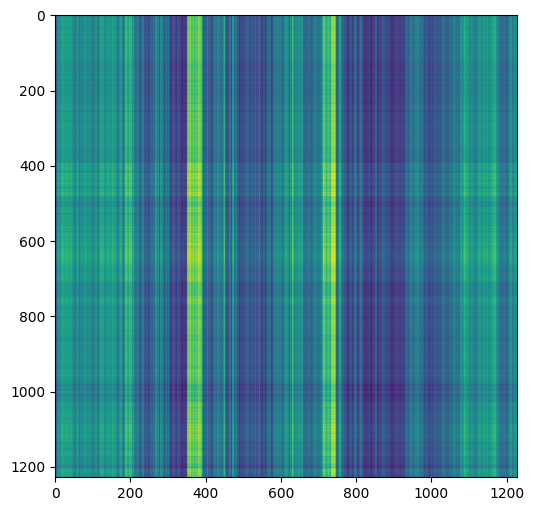

In [139]:
A_flow = make_attention_graph(model_basic, BasicData, model_type= 'Performer' ,fuse="aware")
print(A_flow.shape)
f, ax1 = plt.subplots(1, 1, figsize=(6, 6))
ax1.imshow(A_flow, cmap='viridis', )

Processing layer 0...
  Layer 0, Head 0:
    Mean: 0.000814
    Median: 0.000806
    Min: 0.000091
    Max: 0.002406
    Std: 0.000243
  Layer 0, Head 1:
    Mean: 0.000814
    Median: 0.000794
    Min: 0.000085
    Max: 0.001605
    Std: 0.000299
Processing layer 1...
  Layer 1, Head 0:
    Mean: 0.000814
    Median: 0.000770
    Min: 0.000041
    Max: 0.002285
    Std: 0.000412
  Layer 1, Head 1:
    Mean: 0.000814
    Median: 0.000765
    Min: 0.000207
    Max: 0.001907
    Std: 0.000334
Processing layer 2...
  Layer 2, Head 0:
    Mean: 0.000814
    Median: 0.000803
    Min: 0.000400
    Max: 0.001476
    Std: 0.000170
  Layer 2, Head 1:
    Mean: 0.000814
    Median: 0.000818
    Min: 0.000343
    Max: 0.001347
    Std: 0.000179
Processing layer 3...
  Layer 3, Head 0:
    Mean: 0.000814
    Median: 0.000819
    Min: 0.000404
    Max: 0.001277
    Std: 0.000167
  Layer 3, Head 1:
    Mean: 0.000814
    Median: 0.000788
    Min: 0.000407
    Max: 0.001541
    Std: 0.000176


/opt/anaconda3/envs/urbanity/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


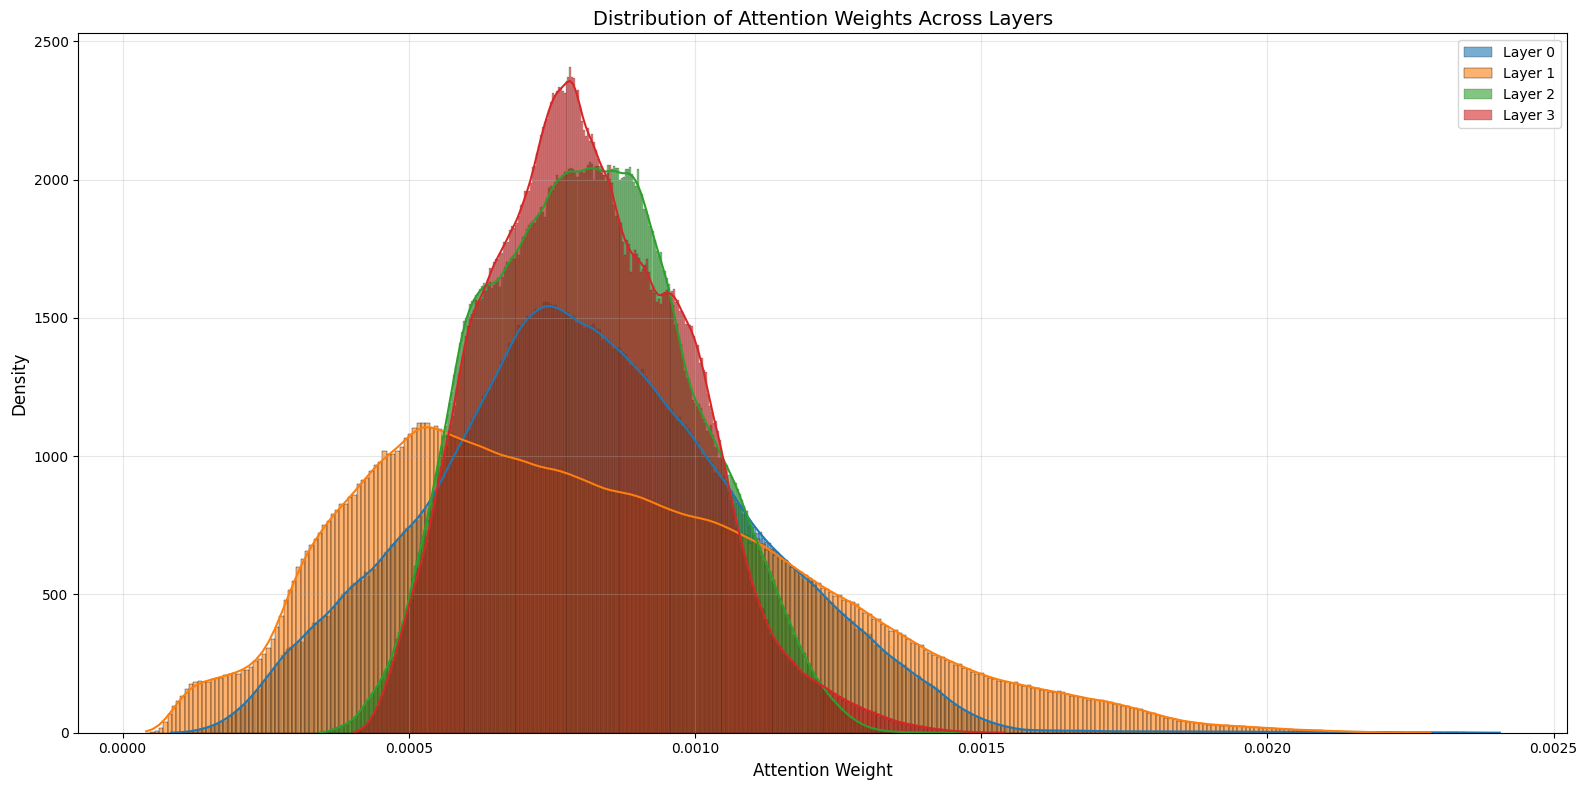

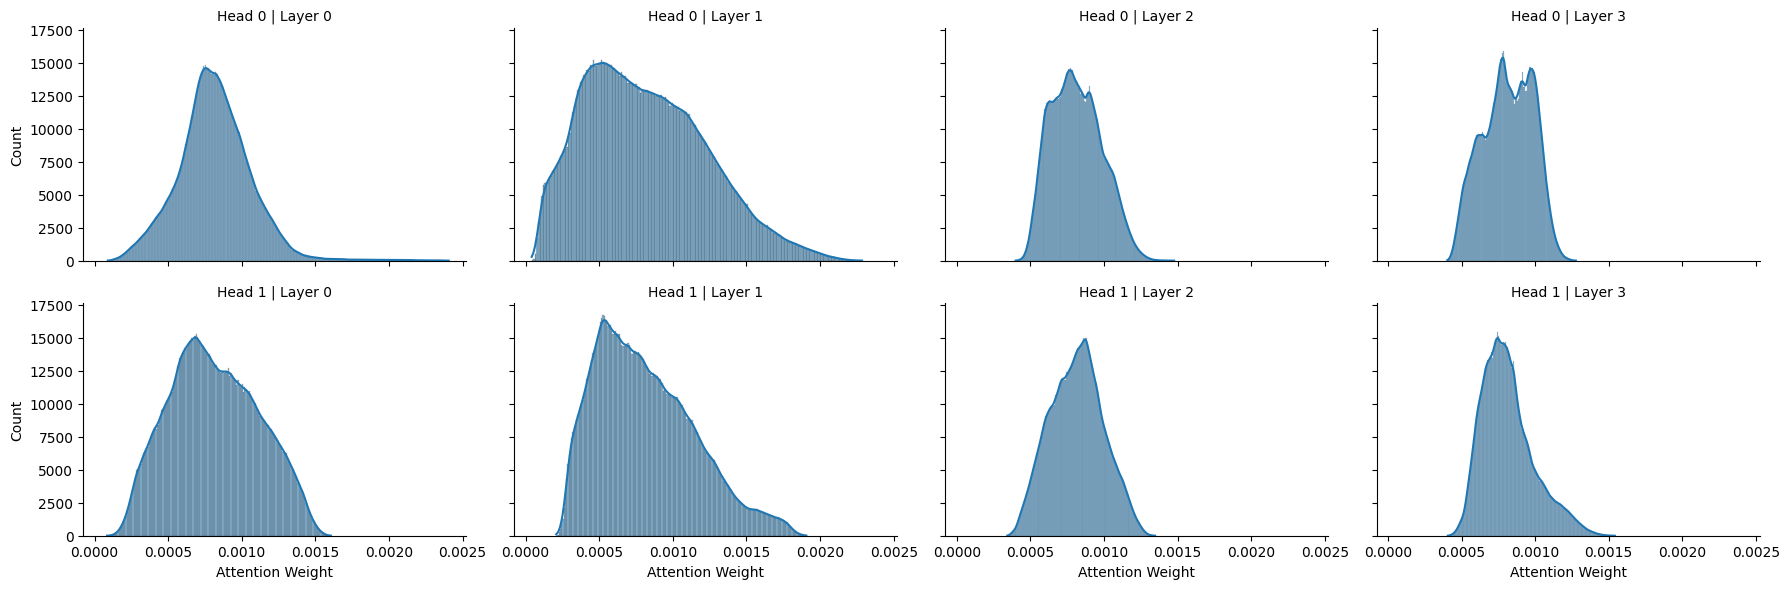

In [140]:
attn_df = analyze_attention_weight_distributions(model_basic, BasicData, num_layers= 4)

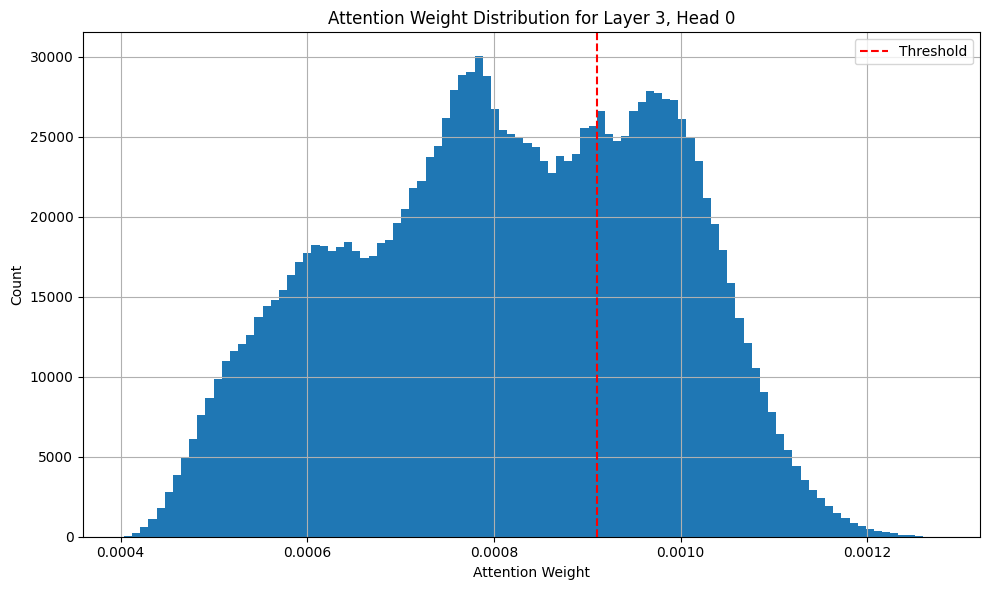

In [141]:
# Load the node mapping for converting between indices and H3 IDs
node_mapping = {node_id: idx for idx, node_id in enumerate(h3_nodes.index)}
reverse_mapping = {idx: h3_id for h3_id, idx in node_mapping.items()}

# Initial visualization of distribution for a specific layer and head
layer = 'Layer 3'
head = 'Head 0'

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
subset = attn_df[(attn_df['layer'] == layer) & (attn_df['head'] == head)]
subset.hist(column='weight', bins=100, ax=ax)
ax.set_title(f'Attention Weight Distribution for {layer}, {head}')
ax.set_xlabel('Attention Weight')
ax.set_ylabel('Count')

# Identify peaks in the distribution
threshold = 0.00091  # Based on your previous analysis
ax.axvline(threshold, color='red', linestyle='--', label='Threshold')
ax.legend()
plt.tight_layout()
plt.show()

Skipping field osmid: unsupported OGR type: 13


<Axes: >

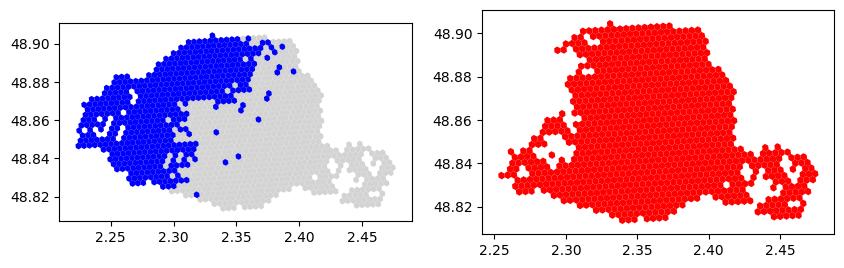

In [142]:
#select weights, target nodes, and source nodes above the threshold
h3_nodes_plotting = gpd.read_file('h3_nodes.geojson')
subset_above_threshold = subset[subset['weight'] > threshold]
subset_above_threshold.head()
subset_below_threshold = subset[subset['weight'] <= threshold]

f, axs = plt.subplots(1, 2, figsize=(10, 6))
h3_nodes_plotting.plot(ax = axs[0], color='lightgrey', markersize=1)
h3_nodes_plotting[h3_nodes_plotting.index.isin(subset_above_threshold['target'])].plot(ax = axs[0], color='blue', markersize=5)

h3_nodes_plotting[h3_nodes_plotting.index.isin(subset_below_threshold['target'])].plot(ax = axs[1], color='red', markersize=5)

Attention still creates regions, but maybe they already look less distinct then with only x, y

## Let's add a total POI feature per each hex

In [147]:
poi_cols = ['Civic', 'Commercial','Entertainment', 'Food', 'Healthcare', 'Institutional', 'Recreational', 'Social']
h3_nodes["POI"] = h3_nodes[poi_cols].sum(axis=1)
X = h3_nodes[['x', 'y','PopSum', 'POI']].values
X = np.array(X)
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)
BasicData = Data(x = torch.FloatTensor(X_scaled), y = torch.FloatTensor(y), edge_index = edge_index )
BasicData = transform(BasicData)
BasicData.train_mask = train_mask   
BasicData.val_mask = val_mask
BasicData.test_mask = test_mask
BasicData.to(device)

Data(x=[1228, 4], edge_index=[2, 6844], y=[1228], pe=[1228, 20], train_mask=[1228], val_mask=[1228], test_mask=[1228])

In [148]:
# Initialize the model
model_basic = HybridModel_variant(
    in_channels=BasicData.num_features,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_transformer_layers=4,
    num_gat_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model_basic.to(device)
assert model_basic(BasicData.x, BasicData.pe ,BasicData.edge_index).squeeze().shape == BasicData.y.shape, "Model output shape does not match target shape"


LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_basic.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30

# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(model_basic, BasicData, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(model_basic, BasicData, BasicData.val_mask, criterion)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        #torch.save(model_basic.state_dict(), 'best_models_paris/best_hybrid_variant_model_basic.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    # Print progress
    if epoch % 10 == 0:
        test_loss = evaluate(model_basic, BasicData, BasicData.test_mask, criterion)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, Counter: {early_stop_counter}')
    
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0327, Val Loss: 0.0122, Test Loss: 0.0086, Counter: 0
Epoch: 020, Train Loss: 0.0139, Val Loss: 0.0149, Test Loss: 0.0113, Counter: 6
Epoch: 030, Train Loss: 0.0101, Val Loss: 0.0094, Test Loss: 0.0068, Counter: 4
Epoch: 040, Train Loss: 0.0090, Val Loss: 0.0091, Test Loss: 0.0067, Counter: 14
Epoch: 050, Train Loss: 0.0082, Val Loss: 0.0091, Test Loss: 0.0065, Counter: 24
Epoch: 060, Train Loss: 0.0085, Val Loss: 0.0086, Test Loss: 0.0062, Counter: 34
Epoch: 070, Train Loss: 0.0082, Val Loss: 0.0085, Test Loss: 0.0061, Counter: 44
Epoch: 080, Train Loss: 0.0085, Val Loss: 0.0083, Test Loss: 0.0060, Counter: 0
Epoch: 090, Train Loss: 0.0078, Val Loss: 0.0083, Test Loss: 0.0060, Counter: 5
Epoch: 100, Train Loss: 0.0081, Val Loss: 0.0082, Test Loss: 0.0059, Counter: 0
Epoch: 110, Train Loss: 0.0082, Val Loss: 0.0082, Test Loss: 0.0059, Counter: 8
Epoch: 120, Train Loss: 0.0077, Val Loss: 0.0081, Test Loss: 0.0058, Counter: 0
Epoch: 1

Final Test Results - Loss: 0.0054


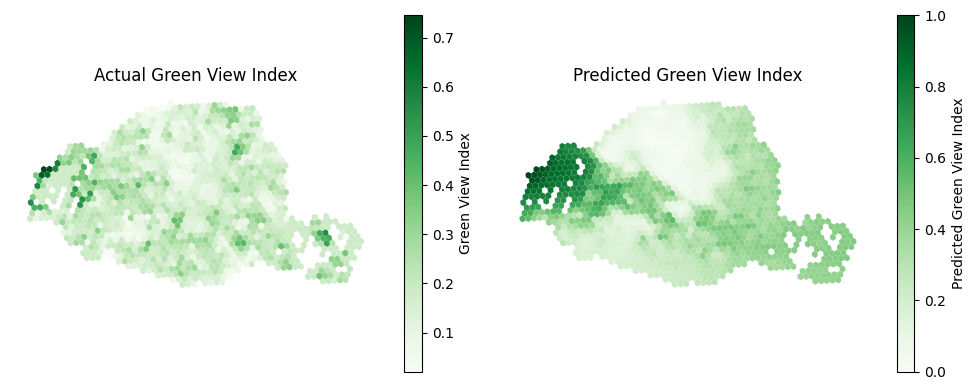

torch.Size([1228, 1228])


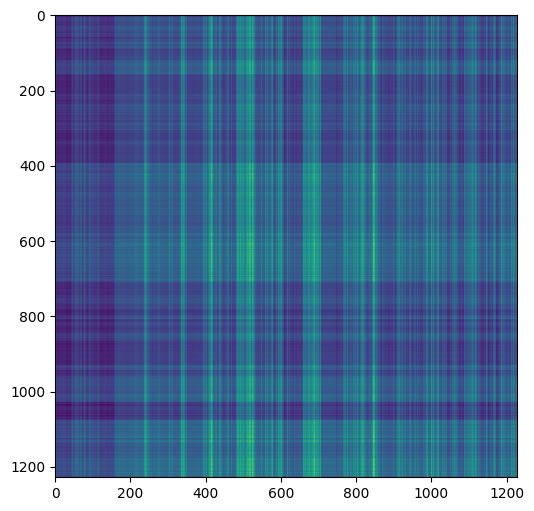

In [149]:
evaluate_and_visualize_predictions(model_basic, BasicData, 'best_models_paris/best_hybrid_variant_model_basic.pth', h3_nodes, criterion, branch='both')
A_flow = make_attention_graph(model_basic, BasicData, model_type= 'Performer' ,fuse="aware")
print(A_flow.shape)
f, ax1 = plt.subplots(1, 1, figsize=(6, 6))
ax1.imshow(A_flow, cmap='viridis', )

Processing layer 0...
  Layer 0, Head 0:
    Mean: 0.000814
    Median: 0.000775
    Min: 0.000037
    Max: 0.002236
    Std: 0.000399
  Layer 0, Head 1:
    Mean: 0.000814
    Median: 0.000793
    Min: 0.000100
    Max: 0.001854
    Std: 0.000316
Processing layer 1...
  Layer 1, Head 0:
    Mean: 0.000814
    Median: 0.000771
    Min: 0.000109
    Max: 0.002197
    Std: 0.000328
  Layer 1, Head 1:
    Mean: 0.000814
    Median: 0.000746
    Min: 0.000105
    Max: 0.004373
    Std: 0.000392
Processing layer 2...
  Layer 2, Head 0:
    Mean: 0.000814
    Median: 0.000833
    Min: 0.000269
    Max: 0.001063
    Std: 0.000120
  Layer 2, Head 1:
    Mean: 0.000814
    Median: 0.000822
    Min: 0.000292
    Max: 0.001288
    Std: 0.000075
Processing layer 3...
  Layer 3, Head 0:
    Mean: 0.000814
    Median: 0.000814
    Min: 0.000554
    Max: 0.000969
    Std: 0.000061
  Layer 3, Head 1:
    Mean: 0.000814
    Median: 0.000827
    Min: 0.000373
    Max: 0.001033
    Std: 0.000074


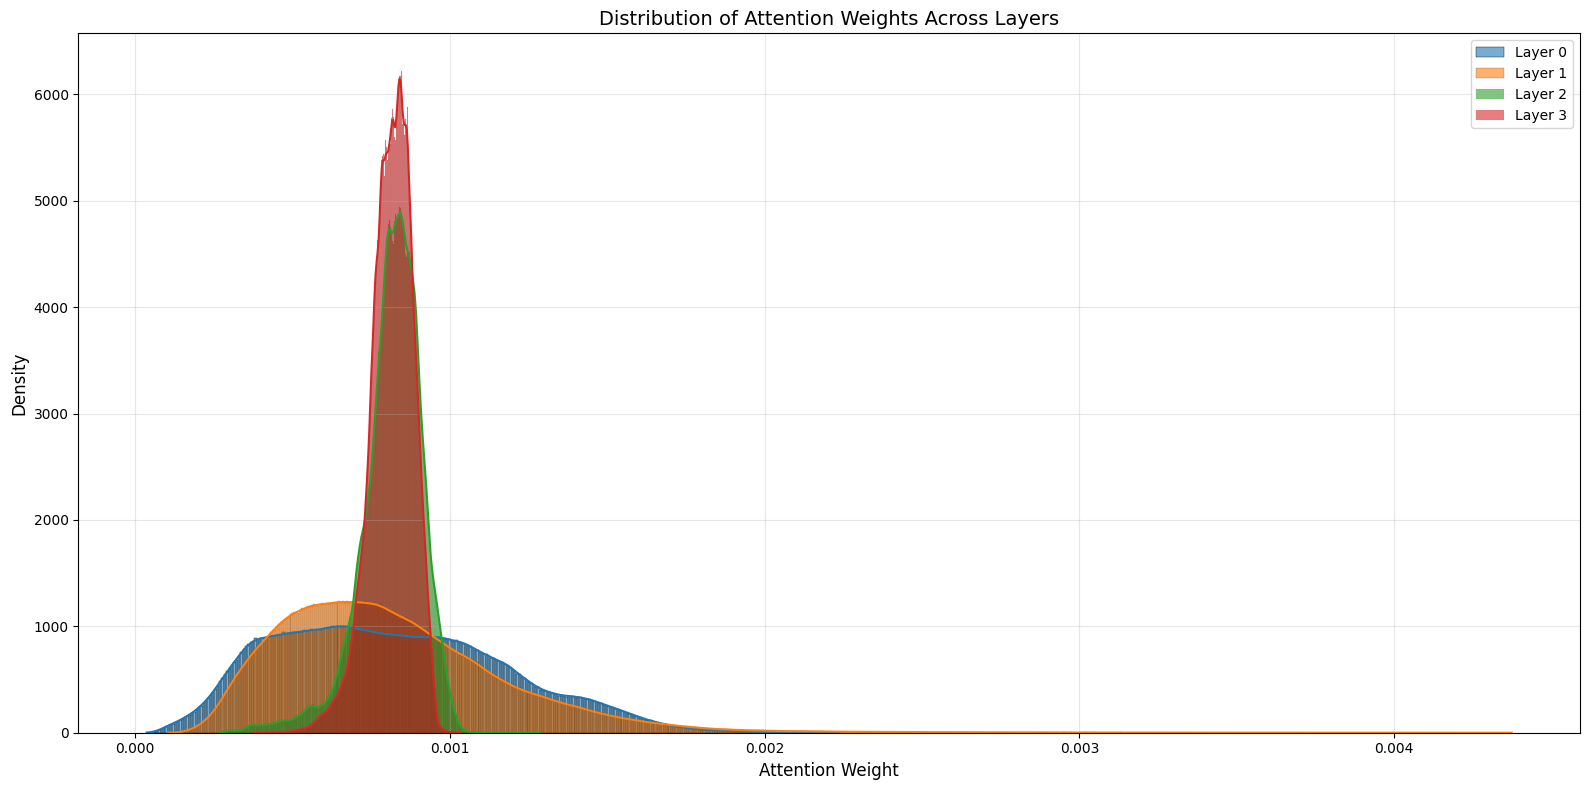

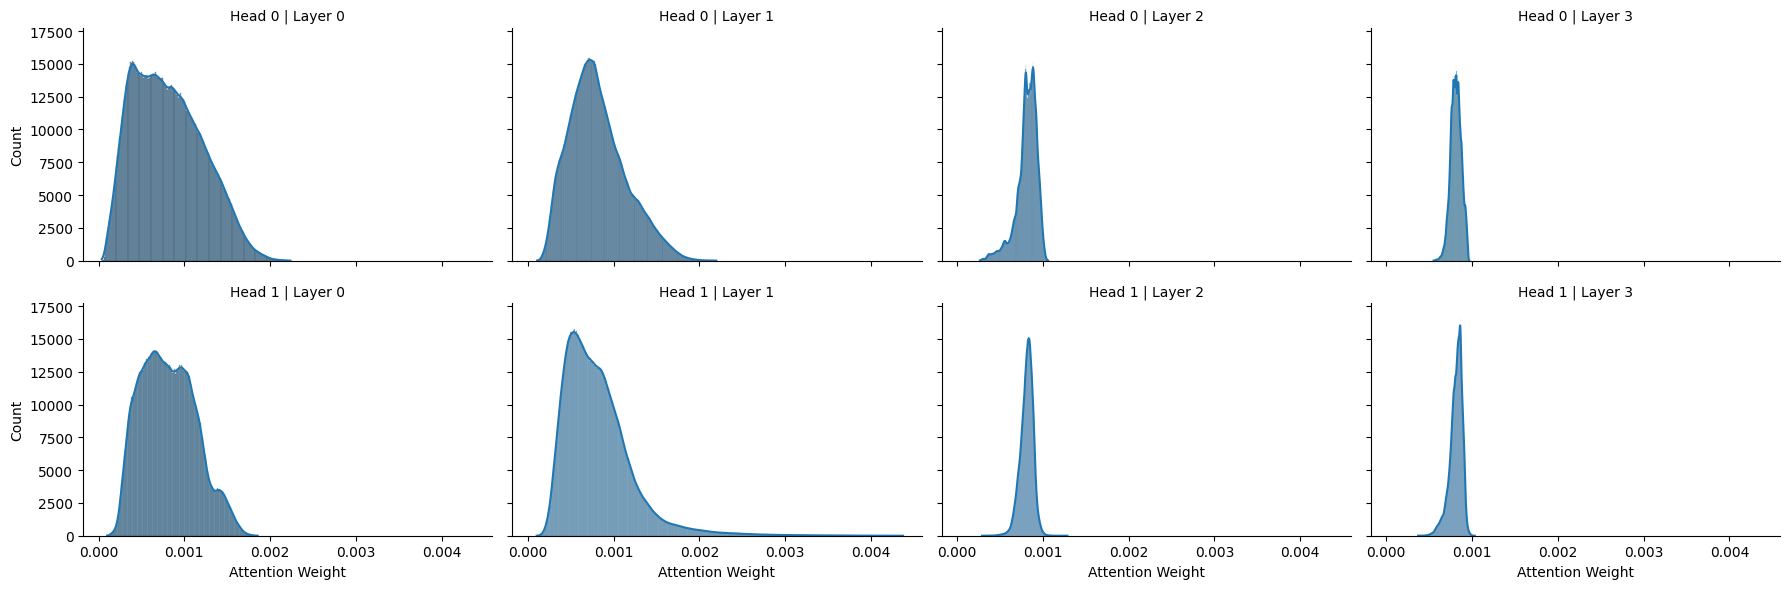

In [103]:
attn_df = analyze_attention_weight_distributions(model_basic, BasicData, num_layers= 4)

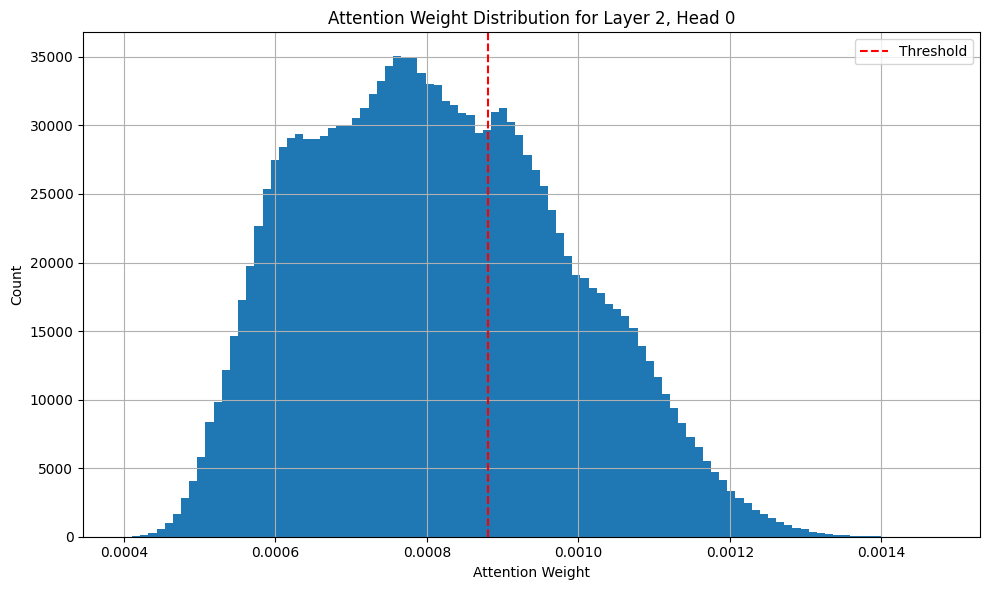

In [151]:
# Load the node mapping for converting between indices and H3 IDs
node_mapping = {node_id: idx for idx, node_id in enumerate(h3_nodes.index)}
reverse_mapping = {idx: h3_id for h3_id, idx in node_mapping.items()}

# Initial visualization of distribution for a specific layer and head
layer = 'Layer 2'
head = 'Head 0'

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
subset = attn_df[(attn_df['layer'] == layer) & (attn_df['head'] == head)]
subset.hist(column='weight', bins=100, ax=ax)
ax.set_title(f'Attention Weight Distribution for {layer}, {head}')
ax.set_xlabel('Attention Weight')
ax.set_ylabel('Count')

# Identify peaks in the distribution
# You could use GMM to identify the components
threshold = 0.00088  # Based on your previous analysis
ax.axvline(threshold, color='red', linestyle='--', label='Threshold')
ax.legend()
plt.tight_layout()
plt.show()

Skipping field osmid: unsupported OGR type: 13


<Axes: >

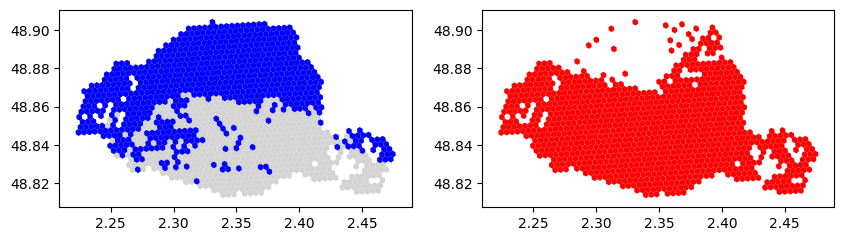

In [152]:
#select weights, target nodes, and source nodes above the threshold
h3_nodes_plotting = gpd.read_file('h3_nodes.geojson')
subset_above_threshold = subset[subset['weight'] > threshold]
subset_above_threshold.head()
subset_below_threshold = subset[subset['weight'] <= threshold]

f, axs = plt.subplots(1, 2, figsize=(10, 6))
h3_nodes_plotting.plot(ax = axs[0], color='lightgrey', markersize=1)
h3_nodes_plotting[h3_nodes_plotting.index.isin(subset_above_threshold['target'])].plot(ax = axs[0], color='blue', markersize=5)

h3_nodes_plotting[h3_nodes_plotting.index.isin(subset_below_threshold['target'])].plot(ax = axs[1], color='red', markersize=5)

I would say that I'm observing what I expected, I'm giving more features to the model and the attention is getting smoother.

## Let's add a total Skyview feature per each hex

In [153]:
X = h3_nodes[['x', 'y','PopSum', 'POI', 'Sky View']].values
X = np.array(X)
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)
BasicData = Data(x = torch.FloatTensor(X_scaled), y = torch.FloatTensor(y), edge_index = edge_index )
BasicData = transform(BasicData)
BasicData.train_mask = train_mask   
BasicData.val_mask = val_mask
BasicData.test_mask = test_mask
BasicData.to(device)

Data(x=[1228, 5], edge_index=[2, 6844], y=[1228], pe=[1228, 20], train_mask=[1228], val_mask=[1228], test_mask=[1228])

In [ ]:
# Initialize the model
model_basic = HybridModel_variant(
    in_channels=BasicData.num_features,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_transformer_layers=4,
    num_gat_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model_basic.to(device)
assert model_basic(BasicData.x, BasicData.pe ,BasicData.edge_index).squeeze().shape == BasicData.y.shape, "Model output shape does not match target shape"


LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_basic.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30

# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(model_basic, BasicData, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(model_basic, BasicData, BasicData.val_mask, criterion)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        #torch.save(model_basic.state_dict(), 'best_models_paris/best_hybrid_variant_skyview.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    # Print progress
    if epoch % 10 == 0:
        test_loss = evaluate(model_basic, BasicData, BasicData.test_mask, criterion)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, Counter: {early_stop_counter}')
    
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0307, Val Loss: 0.0162, Test Loss: 0.0153, Counter: 3
Epoch: 020, Train Loss: 0.0156, Val Loss: 0.0103, Test Loss: 0.0077, Counter: 13
Epoch: 030, Train Loss: 0.0113, Val Loss: 0.0076, Test Loss: 0.0058, Counter: 1
Epoch: 040, Train Loss: 0.0098, Val Loss: 0.0080, Test Loss: 0.0057, Counter: 11
Epoch: 050, Train Loss: 0.0088, Val Loss: 0.0076, Test Loss: 0.0055, Counter: 4
Epoch: 060, Train Loss: 0.0088, Val Loss: 0.0071, Test Loss: 0.0053, Counter: 0
Epoch: 070, Train Loss: 0.0087, Val Loss: 0.0073, Test Loss: 0.0054, Counter: 8
Epoch: 080, Train Loss: 0.0078, Val Loss: 0.0069, Test Loss: 0.0052, Counter: 0
Epoch: 090, Train Loss: 0.0078, Val Loss: 0.0070, Test Loss: 0.0053, Counter: 9
Epoch: 100, Train Loss: 0.0080, Val Loss: 0.0069, Test Loss: 0.0053, Counter: 7
Epoch: 110, Train Loss: 0.0078, Val Loss: 0.0068, Test Loss: 0.0054, Counter: 0
Epoch: 120, Train Loss: 0.0072, Val Loss: 0.0066, Test Loss: 0.0053, Counter: 0
Epoch: 130

Final Test Results - Loss: 0.0035


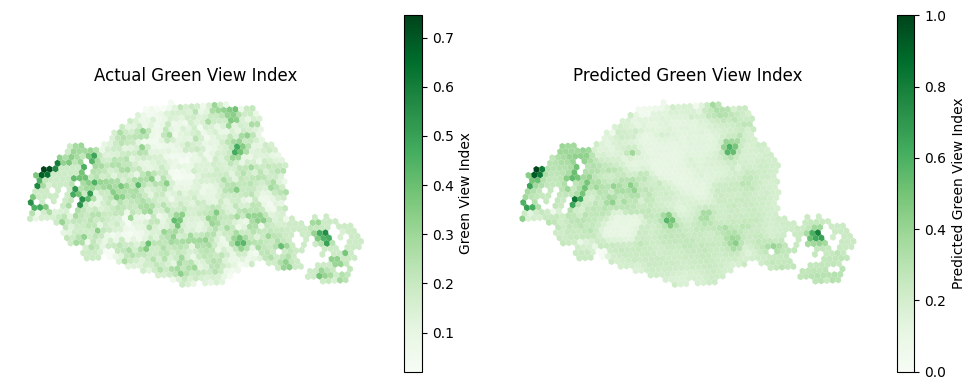

torch.Size([1228, 1228])


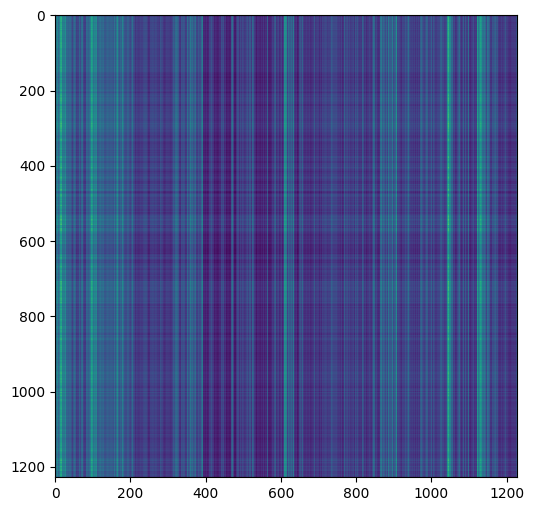

In [155]:
evaluate_and_visualize_predictions(model_basic, BasicData, 'best_models_paris/best_hybrid_variant_model_basic.pth', h3_nodes, criterion, branch='both')
A_flow = make_attention_graph(model_basic, BasicData, model_type= 'Performer' ,fuse="aware")
print(A_flow.shape)
f, ax1 = plt.subplots(1, 1, figsize=(6, 6))
ax1.imshow(A_flow, cmap='viridis', )

Processing layer 0...
  Layer 0, Head 0:
    Mean: 0.000814
    Median: 0.000718
    Min: 0.000016
    Max: 0.002416
    Std: 0.000481
  Layer 0, Head 1:
    Mean: 0.000814
    Median: 0.000785
    Min: 0.000035
    Max: 0.003277
    Std: 0.000387
Processing layer 1...
  Layer 1, Head 0:
    Mean: 0.000814
    Median: 0.000793
    Min: 0.000203
    Max: 0.002340
    Std: 0.000210
  Layer 1, Head 1:
    Mean: 0.000814
    Median: 0.000788
    Min: 0.000203
    Max: 0.002213
    Std: 0.000264
Processing layer 2...
  Layer 2, Head 0:
    Mean: 0.000814
    Median: 0.000775
    Min: 0.000275
    Max: 0.001440
    Std: 0.000205
  Layer 2, Head 1:
    Mean: 0.000814
    Median: 0.000814
    Min: 0.000345
    Max: 0.001266
    Std: 0.000075
Processing layer 3...
  Layer 3, Head 0:
    Mean: 0.000814
    Median: 0.000802
    Min: 0.000152
    Max: 0.002164
    Std: 0.000302
  Layer 3, Head 1:
    Mean: 0.000814
    Median: 0.000794
    Min: 0.000411
    Max: 0.001779
    Std: 0.000134


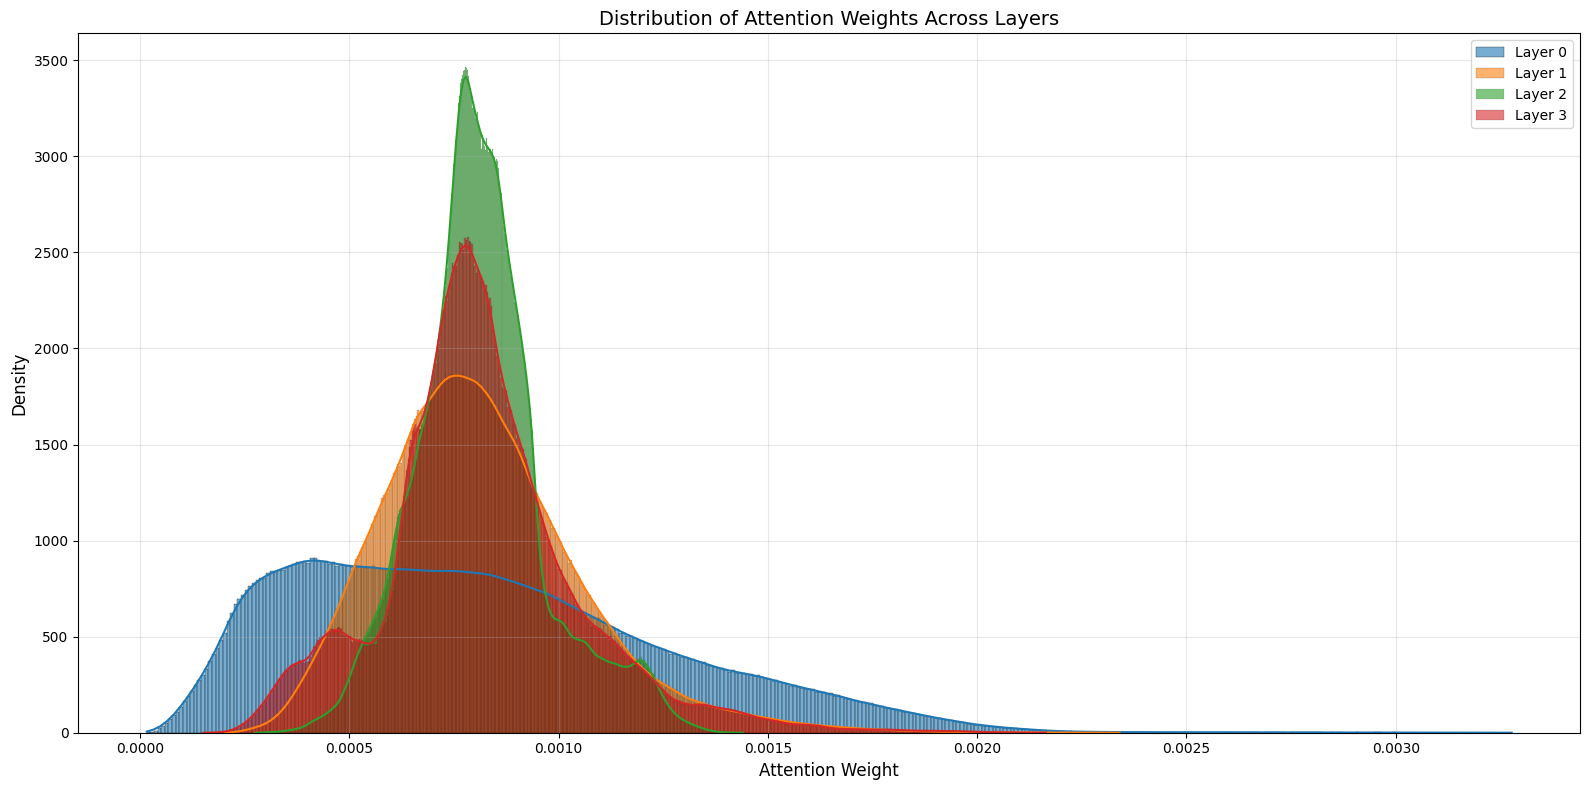

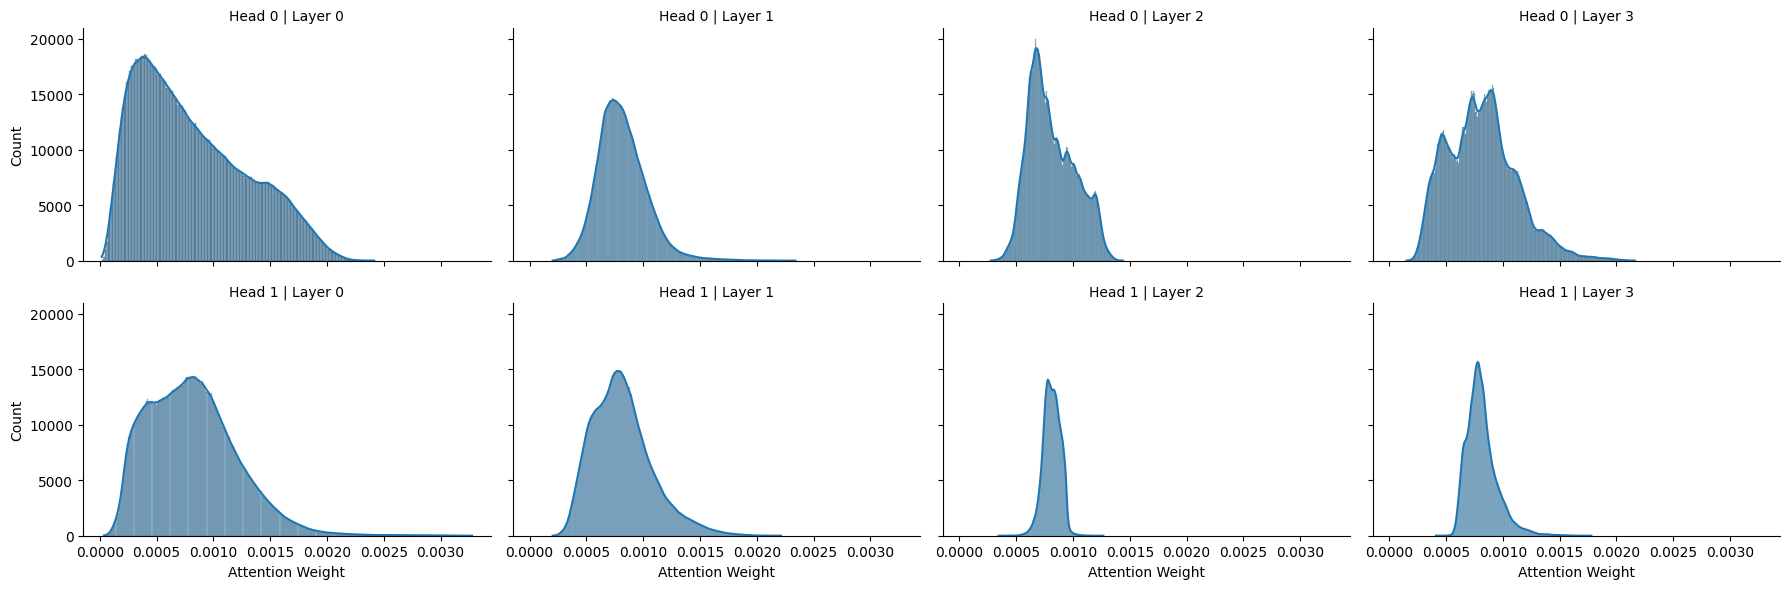

In [156]:
attn_df = analyze_attention_weight_distributions(model_basic, BasicData, num_layers= 4)

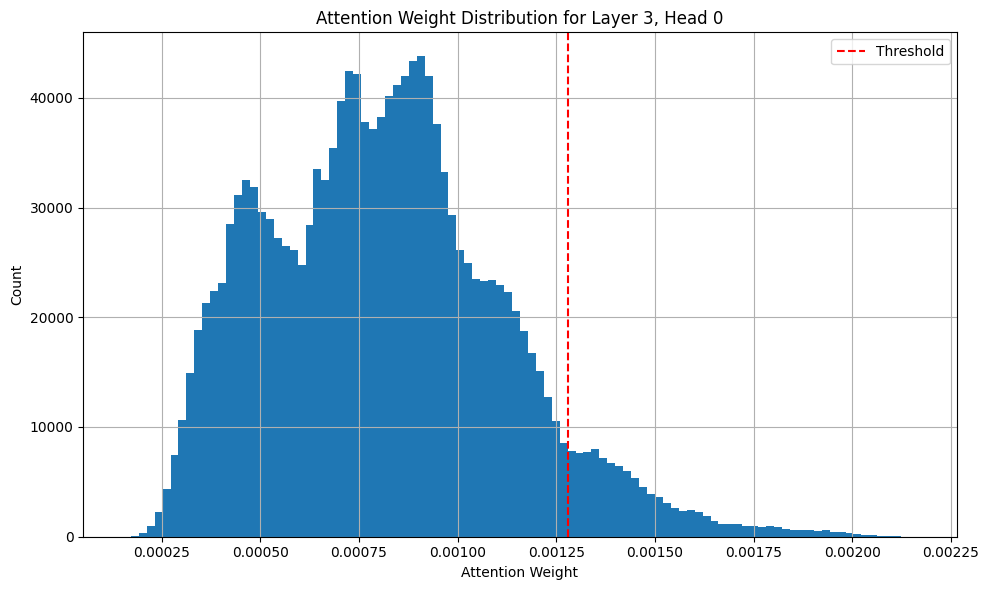

In [167]:
# Load the node mapping for converting between indices and H3 IDs
node_mapping = {node_id: idx for idx, node_id in enumerate(h3_nodes.index)}
reverse_mapping = {idx: h3_id for h3_id, idx in node_mapping.items()}

# Initial visualization of distribution for a specific layer and head
layer = 'Layer 3'
head = 'Head 0'

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
subset = attn_df[(attn_df['layer'] == layer) & (attn_df['head'] == head)]
subset.hist(column='weight', bins=100, ax=ax)
ax.set_title(f'Attention Weight Distribution for {layer}, {head}')
ax.set_xlabel('Attention Weight')
ax.set_ylabel('Count')

# Identify peaks in the distribution
# You could use GMM to identify the components
threshold = 0.00128 # Based on your previous analysis
ax.axvline(threshold, color='red', linestyle='--', label='Threshold')
ax.legend()
plt.tight_layout()
plt.show()

Skipping field osmid: unsupported OGR type: 13


<Axes: >

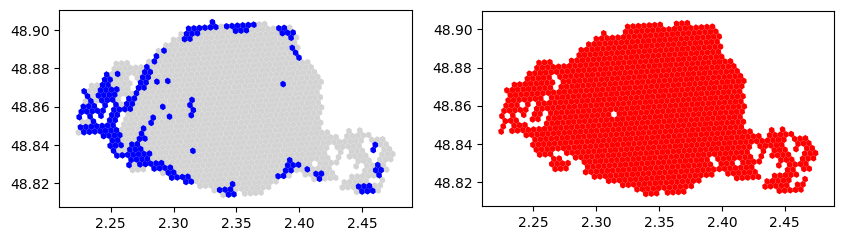

In [168]:
#select weights, target nodes, and source nodes above the threshold
h3_nodes_plotting = gpd.read_file('h3_nodes.geojson')
subset_above_threshold = subset[subset['weight'] > threshold]
subset_above_threshold.head()
subset_below_threshold = subset[subset['weight'] <= threshold]

f, axs = plt.subplots(1, 2, figsize=(10, 6))
h3_nodes_plotting.plot(ax = axs[0], color='lightgrey', markersize=1)
h3_nodes_plotting[h3_nodes_plotting.index.isin(subset_above_threshold['target'])].plot(ax = axs[0], color='blue', markersize=5)

h3_nodes_plotting[h3_nodes_plotting.index.isin(subset_below_threshold['target'])].plot(ax = axs[1], color='red', markersize=5)

## Last check is adding back the positional encoding

In [174]:
class HybridModel_variant(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        num_transformer_layers: int = 2,
        num_gat_layers: int = 2,
        dropout: float = 0.4,
        combine_method: str = 'concat',  # 'concat', 'sum'
    ):
        super().__init__()
        
        # Shared input embedding
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)
        
        # Transformer branch (DeepGraphPerformer)
        self.transformer_layers = nn.ModuleList()
        for _ in range(num_transformer_layers):
            layer = nn.ModuleDict({
                'norm1': nn.LayerNorm(hidden_channels),
                'attention': PerformerAttention(
                    channels=hidden_channels,
                    heads=heads,
                    head_channels=head_channels,
                    kernel=torch.nn.ReLU(),
                    dropout=dropout
                ),
                'norm2': nn.LayerNorm(hidden_channels),
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.transformer_layers.append(layer)
        
        # GAT branch - improved with proper normalization and FFN
        self.gat_layers = nn.ModuleList()
        for _ in range(num_gat_layers):
            layer = nn.ModuleDict({
                # Pre-normalization
                'norm': nn.LayerNorm(hidden_channels),
                
                # GAT component
                'gat': GATv2Conv(
                    hidden_channels, 
                    hidden_channels, 
                    heads=heads, 
                    concat=True, 
                    dropout=dropout
                ),
                
                # Post-normalization
                'gat_norm': nn.LayerNorm(hidden_channels*heads),
                
                # Feed-forward network
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels*heads, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.gat_layers.append(layer)
        
        # Layer normalization for transformer and GAT outputs before combining
        self.transformer_norm = nn.LayerNorm(hidden_channels)
        self.gat_norm = nn.LayerNorm(hidden_channels)
        
        # Combination method
        self.combine_method = combine_method
        if combine_method == 'concat':
            self.combine = nn.Linear(hidden_channels * 2, hidden_channels)
        
        # Output layer for node prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def forward(self, x, pe, edge_index, branch='both'):
        """
        Forward pass with option to use specific branches.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            branch: Which branch to use ('both', 'gat', or 'performer')
        """
        # Initial embedding
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        if branch in ['both', 'performer']:
            # Transformer branch
            transformer_x = x
            for layer in self.transformer_layers:
                # Attention block with residual
                residual = transformer_x
                transformer_x_norm = layer['norm1'](transformer_x)
                transformer_x_attn = transformer_x_norm.unsqueeze(0)
                transformer_x_attn = layer['attention'](transformer_x_attn)
                transformer_x = transformer_x_attn.squeeze(0) + residual
                
                # FFN block with residual
                residual = transformer_x
                transformer_x = layer['norm2'](transformer_x)
                transformer_x = layer['ffn'](transformer_x) + residual
            
            transformer_x = self.transformer_norm(transformer_x)
        
        if branch in ['both', 'gat']:
            # GAT branch - improved with proper residuals and FFN
            gat_x = x
            for layer in self.gat_layers:
                # Pre-normalization
                gat_x_norm = layer['norm'](gat_x)
                
                # Apply GAT 
                gat_x_attn = layer['gat'](gat_x_norm, edge_index)
                gat_x_attn = layer['gat_norm'](gat_x_attn)
                
                # Apply FFN with residual
                gat_x_ff = layer['ffn'](gat_x_attn)
                
                # Add residual connection from before GAT (matches GAT_model design)
                gat_x = gat_x + gat_x_ff
            
            gat_x = self.gat_norm(gat_x)
        
        # Combine or use individual branch based on parameter
        if branch == 'both':
            if self.combine_method == 'sum':
                combined_x = transformer_x + gat_x
            elif self.combine_method == 'concat':
                combined_x = torch.cat([transformer_x, gat_x], dim=1)
                combined_x = F.relu(self.combine(combined_x))
        elif branch == 'performer':
            combined_x = transformer_x
        elif branch == 'gat':
            combined_x = gat_x
        
        # Final prediction
        return self.output_layer(combined_x)
    
    def redraw_projection_matrix(self):
        """Redraw projection matrices in all attention layers."""
        for layer in self.transformer_layers:
            attention = layer['attention']
            attention.redraw_projection_matrix()
    
    def get_performer_attention(self, x, pe, edge_index, layer_idx=0, mask=None):
        """Extract the attention approximation used by Performer for a specific layer.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            layer_idx: Index of the layer to extract attention from (default: 0)
            mask: Optional mask
            
        Returns:
            Tensor of shape [heads, num_nodes, num_nodes] representing attention weights
        """
        if layer_idx < 0 or layer_idx >= len(self.transformer_layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.transformer_layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            transformer_x = x
            
            # Process through previous transformer layers
            for i in range(layer_idx):
                layer = self.transformer_layers[i]
                # Attention block with residual
                residual = transformer_x
                transformer_x_norm = layer['norm1'](transformer_x)
                transformer_x_attn = transformer_x_norm.unsqueeze(0)
                transformer_x_attn = layer['attention'](transformer_x_attn)
                transformer_x = transformer_x_attn.squeeze(0) + residual
                
                # FFN block with residual
                residual = transformer_x
                transformer_x = layer['norm2'](transformer_x)
                transformer_x = layer['ffn'](transformer_x) + residual
            
            # Get the target layer
            layer = self.transformer_layers[layer_idx]
            transformer_x_norm = layer['norm1'](transformer_x)
            
            # Add batch dimension for attention
            x = transformer_x_norm.unsqueeze(0)
            
            # Get Q, K, V projections
            attention = layer['attention']
            B, N, C = x.shape
            q, k, v = attention.q(x), attention.k(x), attention.v(x)
            
            # Reshape to multi-head format
            q, k, v = map(
                lambda t: t.reshape(B, N, attention.heads, attention.head_channels).permute(
                    0, 2, 1, 3), (q, k, v))
            
            # Apply the kernel approximation to q and k
            fast_attn = attention.fast_attn
            q_prime = generalized_kernel(q, fast_attn.projection_matrix, fast_attn.kernel)
            k_prime = generalized_kernel(k, fast_attn.projection_matrix, fast_attn.kernel)
            
            # Compute approximate attention matrix
            k_prime_sum = k_prime.sum(dim=-2, keepdim=True)
            
            # For explicit attention weights
            attention_weights = []
            for h in range(attention.heads):
                head_q = q_prime[0, h]  # [N, features]
                head_k = k_prime[0, h]  # [N, features]
                
                # Compute normalized attention (shape: [N, N])
                attn_mat = torch.zeros(N, N, device=q.device)
                for i in range(N):
                    q_i = head_q[i:i+1]  # [1, features]
                    # Normalized kernel dot product for each node pair
                    attn_i = (q_i @ head_k.transpose(-1, -2)) / (q_i @ k_prime_sum[0, h].transpose(-1, -2))
                    attn_mat[i] = attn_i
                
                attention_weights.append(attn_mat)
            
            return torch.stack(attention_weights)  # [heads, N, N]
    
    def get_attention_weights(self, x, pe, edge_index, layer_idx=0):
        """Extract the attention weights from GATv2Conv for a specific layer.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            layer_idx: Index of the layer to extract attention from (default: 0)
            
        Returns:
            Tuple of (edge_index, attention_weights) where attention_weights has
            shape [num_edges, heads]
        """
        if layer_idx < 0 or layer_idx >= len(self.gat_layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.gat_layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            gat_x = x
            
            # Process through previous layers using the proper GAT layer structure
            for i in range(layer_idx):
                layer = self.gat_layers[i]
                # Pre-normalization
                gat_x_norm = layer['norm'](gat_x)
                
                # Apply GAT 
                gat_x_attn = layer['gat'](gat_x_norm, edge_index)
                gat_x_attn = layer['gat_norm'](gat_x_attn)
                
                # Apply FFN with residual
                gat_x_ff = layer['ffn'](gat_x_attn)
                
                # Add residual connection from before GAT
                gat_x = gat_x + gat_x_ff
            
            # Get the target layer
            layer = self.gat_layers[layer_idx]
            gat_x_norm = layer['norm'](gat_x)
            
            # Return the edge_index and attention weights for the target layer
            # For GATv2Conv, we need to use return_attention_weights=True
            _, (att_edge_ind, attention_weights) = layer['gat'](
                gat_x_norm, edge_index, return_attention_weights=True)
            
            # The attention weights will have shape [num_edges, heads]
            return att_edge_ind, attention_weights
        

# Initialize the model
model_basic = HybridModel_variant(
    in_channels=BasicData.num_features,
    pe_input_dim=BasicData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_transformer_layers=4,
    num_gat_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model_basic.to(device)
assert model_basic(BasicData.x, BasicData.pe, BasicData.edge_index).squeeze().shape == BasicData.y.shape, "Model output shape does not match target shape"

In [175]:
LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_basic.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30

# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(model_basic, BasicData, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(model_basic, BasicData, BasicData.val_mask, criterion)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model_basic.state_dict(), 'best_models_paris/best_hybrid_variant_skyview.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    # Print progress
    if epoch % 10 == 0:
        test_loss = evaluate(model_basic, BasicData, BasicData.test_mask, criterion)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, Counter: {early_stop_counter}')
    
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0235, Val Loss: 0.0128, Test Loss: 0.0131, Counter: 2
Epoch: 020, Train Loss: 0.0142, Val Loss: 0.0094, Test Loss: 0.0071, Counter: 6
Epoch: 030, Train Loss: 0.0113, Val Loss: 0.0077, Test Loss: 0.0058, Counter: 3
Epoch: 040, Train Loss: 0.0107, Val Loss: 0.0075, Test Loss: 0.0057, Counter: 0
Epoch: 050, Train Loss: 0.0096, Val Loss: 0.0073, Test Loss: 0.0055, Counter: 5
Epoch: 060, Train Loss: 0.0102, Val Loss: 0.0070, Test Loss: 0.0053, Counter: 1
Epoch: 070, Train Loss: 0.0090, Val Loss: 0.0068, Test Loss: 0.0053, Counter: 0
Epoch: 080, Train Loss: 0.0088, Val Loss: 0.0069, Test Loss: 0.0053, Counter: 8
Epoch: 090, Train Loss: 0.0088, Val Loss: 0.0068, Test Loss: 0.0053, Counter: 2
Epoch: 100, Train Loss: 0.0085, Val Loss: 0.0067, Test Loss: 0.0053, Counter: 2
Epoch: 110, Train Loss: 0.0086, Val Loss: 0.0066, Test Loss: 0.0053, Counter: 0
Epoch: 120, Train Loss: 0.0087, Val Loss: 0.0067, Test Loss: 0.0053, Counter: 7
Epoch: 130, 

Final Test Results - Loss: 0.0035


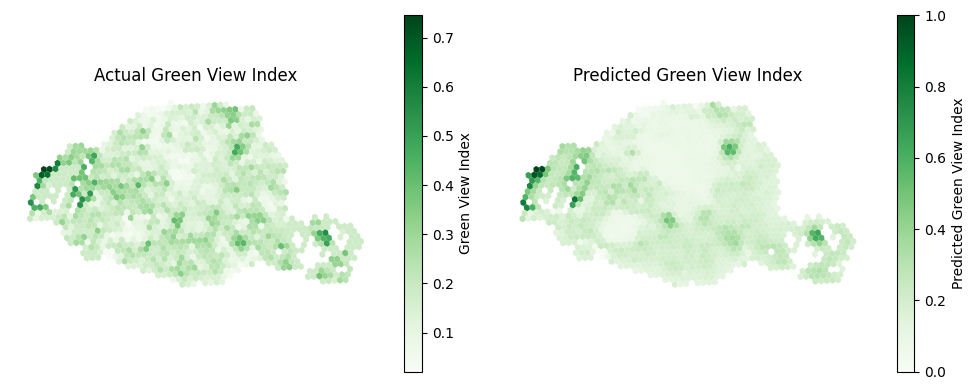

torch.Size([1228, 1228])


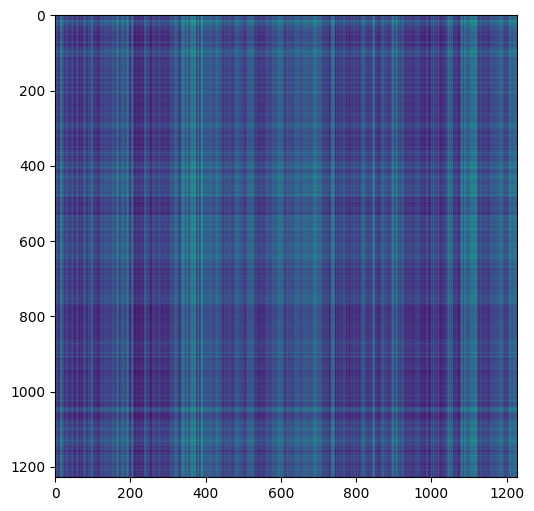

In [176]:
evaluate_and_visualize_predictions(model_basic, BasicData, '', h3_nodes, criterion, branch='both')
A_flow = make_attention_graph(model_basic, BasicData, model_type= 'Performer' ,fuse="aware")
print(A_flow.shape)
f, ax1 = plt.subplots(1, 1, figsize=(6, 6))
ax1.imshow(A_flow, cmap='viridis', )

Processing layer 0...
  Layer 0, Head 0:
    Mean: 0.000814
    Median: 0.000815
    Min: 0.000053
    Max: 0.003858
    Std: 0.000313
  Layer 0, Head 1:
    Mean: 0.000814
    Median: 0.000755
    Min: 0.000064
    Max: 0.002245
    Std: 0.000365
Processing layer 1...
  Layer 1, Head 0:
    Mean: 0.000814
    Median: 0.000782
    Min: 0.000138
    Max: 0.003186
    Std: 0.000256
  Layer 1, Head 1:
    Mean: 0.000814
    Median: 0.000786
    Min: 0.000109
    Max: 0.002046
    Std: 0.000317
Processing layer 2...
  Layer 2, Head 0:
    Mean: 0.000814
    Median: 0.000778
    Min: 0.000136
    Max: 0.002341
    Std: 0.000286
  Layer 2, Head 1:
    Mean: 0.000814
    Median: 0.000770
    Min: 0.000234
    Max: 0.002351
    Std: 0.000214
Processing layer 3...
  Layer 3, Head 0:
    Mean: 0.000814
    Median: 0.000814
    Min: 0.000498
    Max: 0.001372
    Std: 0.000081
  Layer 3, Head 1:
    Mean: 0.000814
    Median: 0.000785
    Min: 0.000379
    Max: 0.001717
    Std: 0.000174


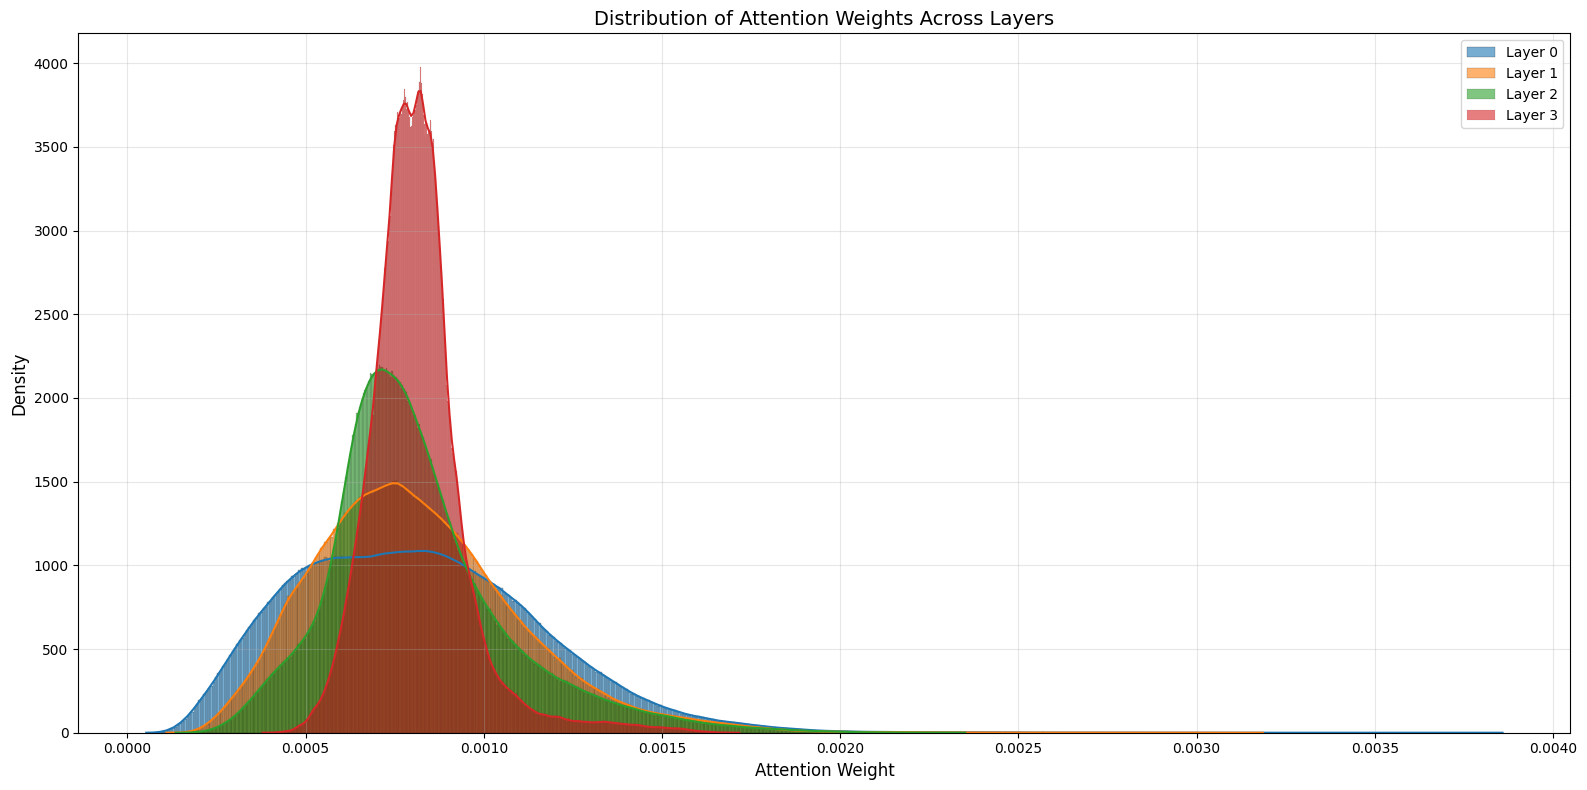

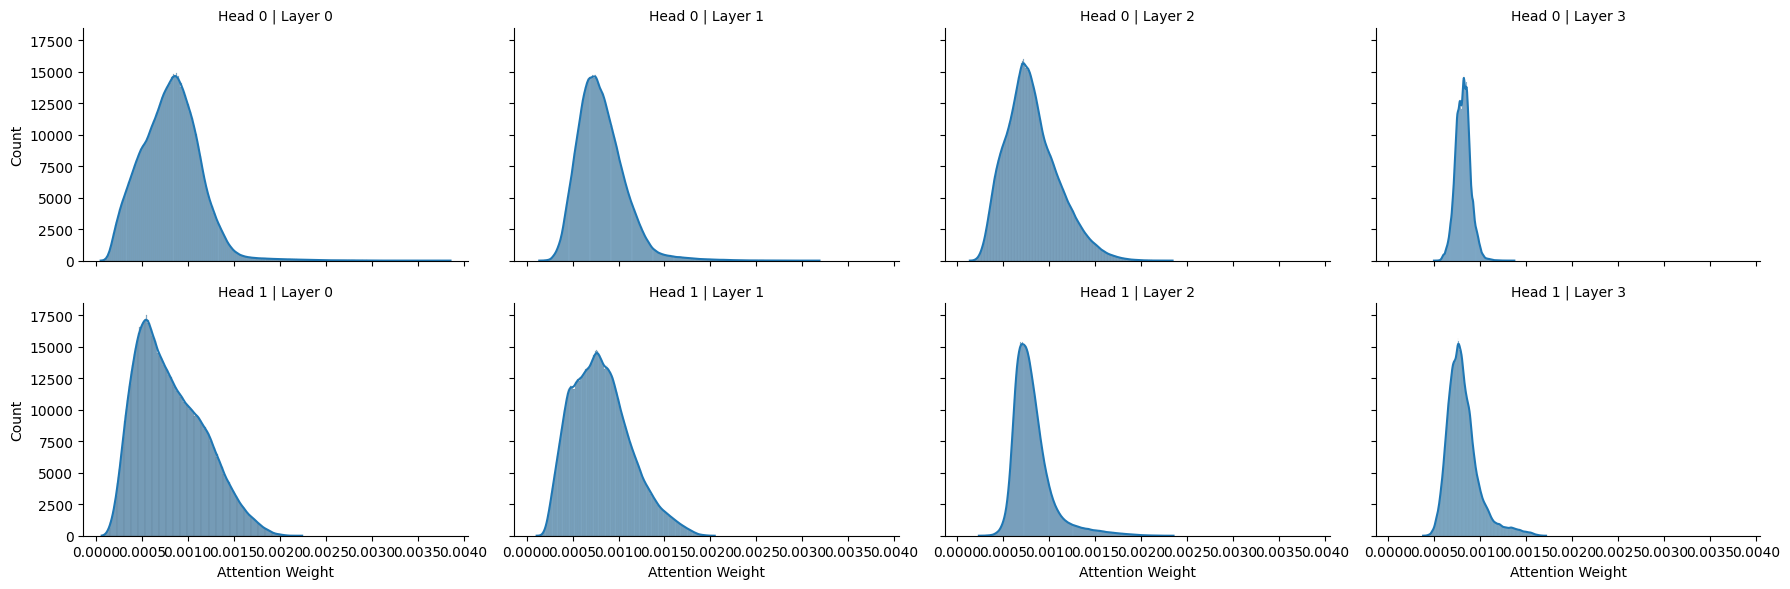

In [173]:
attn_df = analyze_attention_weight_distributions(model_basic, BasicData, num_layers= 4)